# Steam Reviews Analysis

[Steam](https://store.steampowered.com/) is a video game platform which allows players to buy, play and rate their favourite games, as well as leaving reviews on them.

This notebook contains a text mining analysis involving the reviews left on the website for some popular video games, with the intention to gain insights on the key features of a game which leave a more long lasting impact on players and shape their opinion on it.

## Import packages

In [1]:
options(warn = -1)
library(tidyverse)
library(rvest)
library(jsonlite)
library(jsonify)
library(quanteda)
library(quanteda.textplots)
library(quanteda.textstats)
library(stopwords)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Caricamento pacchetto: 'rvest'


Il seguente oggetto è mascherato da 'package:readr':

    guess_encoding



Caricamento pacchetto: 'jsonlite'


Il seguente oggetto è mascherato da 'package:purrr':

    flatten


Registered S3 method overwritten by 'jsonify':
  method     from    
  print.json jsonlite

Package version: 4.3.1
Unicode version: 15.1
ICU version: 74.1

Parallel computing: 8 of 8 threads used.

See https://quanteda.io for tutorials and examples.



These are the modules we are going to use:
- *tidyverse* makes the syntax of the commands easier and cleanier;
- *rvest* is useful to scrape data from web pages;
- *jsonlite* and *jsonify* allow us to parse and treat data in JSON format;
- *quanteda* is extremely helpful for anything regarding text mining analysis;
- *stopwords* contains a list of stopwords, i.e. words that are not interesting for text analysis.

## Retrieve data

Fortunately for us, Steam provides a free API with few restrictions, which makes it easy to retrieve data of any kind from the website, including the games reviews.

By reading the [official documentation](https://partner.steamgames.com/doc/store/getreviews), we can find the API endpoint we are interested in and the parameters we can pass to it to modify the response.

We still have to choose which games we are going to pick for our analysis. A good idea could be to use the 25 most played games on Steam, a list which can be found on this [webpage](https://steamcharts.com/top).

In [2]:
# make a request to the website for that page
page <- read_html("https://steamcharts.com/top")

# find the HTML elements which contain the ids of the games
games_elements <- page %>% html_elements(css = "a[href*='app']")

game_ids <- vector()

# save the ids into a vector
for (game_element in games_elements) {
    game_id <- game_element %>% html_attr("href") %>% strsplit("app/") %>% unlist() %>% tail(n = 1)
    game_ids <- append(game_ids, game_id)
}

print(game_ids)

 [1] "730"     "578080"  "570"     "1172470" "2507950" "3419430" "1203220"
 [8] "252490"  "413150"  "431960"  "2923300" "271590"  "2584990" "359550" 
[15] "2767030" "294100"  "236390"  "381210"  "2669320" "2252570" "1623730"
[22] "480"     "553850"  "3240220" "2622380"


Now that we have got the identifiers for the games, we can use the API to get their reviews.

In [3]:
reviews_texts <- vector()

for (game_id in game_ids) {

    # limit the number of reviews to 10 (default is 20)
    api_endpoint <- paste("https://store.steampowered.com/appreviews/", game_id, "?json=1&purchase_type=all&num_per_page=10", sep="")

    # get the reviews for the game
    reviews <- api_endpoint %>% fromJSON() %>% .$reviews %>% .$review
    # save the reviews to a vector
    reviews_texts <- reviews_texts %>% c(reviews)
}

# dump the reviews into a separate file to easily access them later
write(toJSON(reviews_texts), "reviews.json")

# print a sample review
print(reviews_texts[1])

[1] "This community is so nice. I got a lot of tips on how to uninstall the game and what to do with myself."


## Text Mining Analysis

We are all set: let's import the reviews from the file and start our text mining analysis.

In [4]:
reviews <- fromJSON("reviews.json")

corpus_reviews <- corpus(reviews)

The technical term for the totality of our reviews (or, more generally, of our texts), is *corpus*. Here we use the *corpus()* function from the *quanteda* package to make R treat our reviews data as a corpus, so that we can apply some specific functions and do a more structured analysis with it.

In [5]:
tokens <- tokens(corpus_reviews, what = "word", remove_punct = TRUE, remove_symbols = TRUE) %>% tokens_tolower()
tokens

Tokens consisting of 240 documents.
text1 :
 [1] "this"      "community" "is"        "so"        "nice"      "i"        
 [7] "got"       "a"         "lot"       "of"        "tips"      "on"       
[ ... and 11 more ]

text2 :
 [1] "they"     "don’t"    "ban"      "cheaters" "at"       "all"     
 [7] "in"       "fact"     "i"        "feel"     "like"     "they"    
[ ... and 55 more ]

text3 :
 [1] "the"      "time"     "i"        "spent"    "playing"  "this"    
 [7] "game"     "could've" "been"     "spent"    "studying" "applying"
[ ... and 94 more ]

text4 :
 [1] "download" "game"     "practice" "get"      "good"     "start"   
 [7] "to"       "enjoy"    "the"      "game"     "bc"       "you"     
[ ... and 50 more ]

text5 :
 [1] "even"       "though"     "this"       "is"         "made"      
 [6] "by"         "valve"      "themselves" "it's"       "absolutely"
[11] "crazy"      "to"        
[ ... and 607 more ]

text6 :
 [1] "even"      "though"    "june"      "men’s"     "menta

Each portion of text in our data is a *token*: they could be smaller sentences, words, characters, etc. Here we choose to consider individual words as tokens.

We make sure to remove punctuation and symbols and transform everything to lowercase, since these are conventions that are useful for human reading, but not necessary for automated analysis.

In [6]:
dfm_reviews <- tokens %>% dfm() %>% dfm_wordstem() %>% dfm_remove(stopwords("english"))
dfm_reviews

Document-feature matrix of: 240 documents, 3,929 features (98.46% sparse) and 0 docvars.
       features
docs    communiti nice got lot tip uninstal game don’t ban cheater
  text1         1    1   1   1   1        1    1     0   0       0
  text2         0    0   0   0   0        0    2     1   1       1
  text3         0    0   1   0   0        1    3     0   0       0
  text4         0    0   0   0   0        1    3     0   1       0
  text5         0    0   1   0   0        0   15     0   2       0
  text6         0    0   0   0   0        0    0     0   0       0
[ reached max_ndoc ... 234 more documents, reached max_nfeat ... 3,919 more features ]

Here we have created a DFM (document-feature matrix), which is a matrix where each row corresponds to a text of our corpus and each column corresponds to a feature (in our case, a term). Each element indicates the frequency of the term in the document (that is, the total number of times it appears in the document).

As we can see, we have got 4,055 terms and a sparsity of 98.40%: there is a high percentage of elements of the matrix whose value is 0. This is a common characteristic of document-feature matrices, as words that get used in a text may not appear in others.

We have also removed stopwords (words that do not bring significant value to our analysis, such as prepositions, articles, and so on) and we have applied stemming to the remaining words: that means that each word was reduced to its root form, just as it happens in a dictionary. This is needed because we are often not focused on the specific inflection of the word in the context, but rather the generic idea which is associated with it.

In [7]:
topfeatures(dfm_reviews, 15) %>% print()

  game   play   just   like    get    can      b player   time   even   make 
   675    218    185    176    174    149    149    129    118    104    103 
   one   good    fun   feel 
   103     89     88     87 


These are the 15 most common terms in our corpus: as we could expect, we have words like "game", "play", "good", and so on.

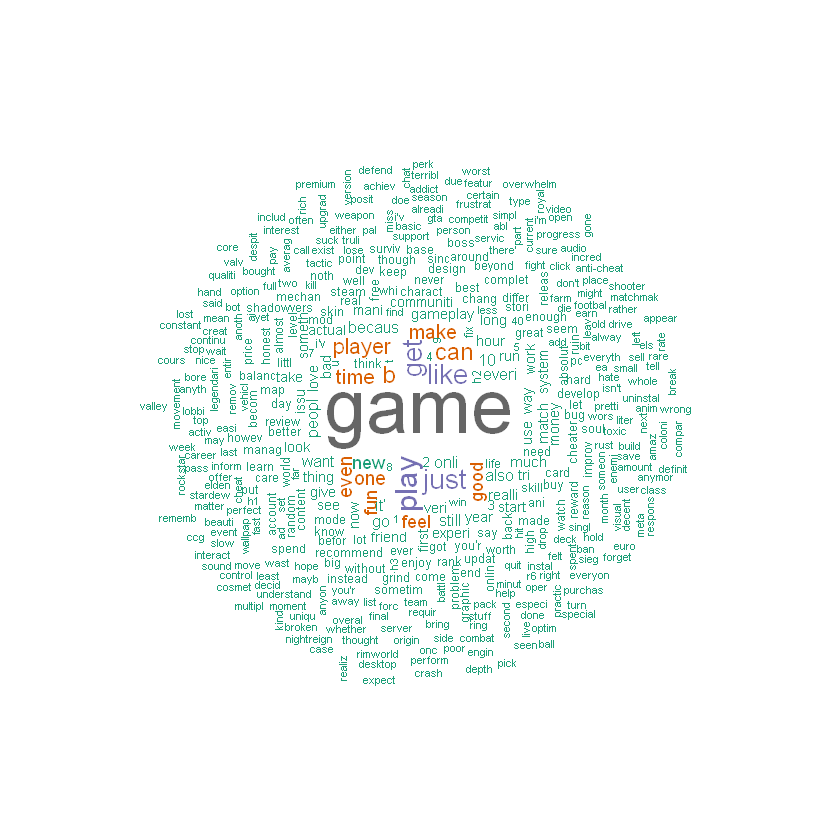

In [8]:

textplot_wordcloud(dfm_reviews, min_count = 10, random_order = FALSE, rotation = 0.25,
color = RColorBrewer::brewer.pal(8, "Dark2"))

This is the same information conveyed in a graphical format: it's a *word cloud*, where the size of the font of each word is proportional to its frequency. In the middle of cloud we see the bigger words, which are also the most frequent, and they are surrounded by all the remaining words with smaller font and lower frequency.

In [9]:
kwic(tokens, "game", window=10)[1:5,]

docname,from,to,pre,keyword,post,pattern
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<fct>
text1,17,17,got a lot of tips on how to uninstall the,game,and what to do with myself,game
text2,17,17,in fact i feel like they even support them the,game,is full of trolls these players have tons of reports,game
text2,54,54,completely what’s the point of the reporting system then this,game,is literally laughing in your face the anticheat might as,game
text3,7,7,the time i spent playing this,game,could've been spent studying applying for jobs making friends irl,game
text3,41,41,man in general from the time i spent in this,game,i got an extremely racist and homophobic vocabulary free russian,game


The *kwic* function locates keywords-in-context: it provides the context in which a word was used in the original texts, with the words preceding and following it.

In [10]:
readability_dale_chall <- corpus_reviews %>% textstat_readability(measure = "Dale.Chall") %>% arrange(Dale.Chall)
mean(readability_dale_chall$Dale.Chall)

readability_flesch <- corpus_reviews %>% textstat_readability(measure = "Flesch") %>% arrange(Flesch)
mean(readability_flesch$Flesch)


[1] 26.11625

[1] 62.41284

Another feature of the texts we may be interested in is their readability: that is, how easily accessible they are for a reader. This is measured considering the number of words, sentences, syllabes in the text or their difficulty.

The Dale-Chall measure was recently [improved](https://readabilityformulas.com/learn-about-the-new-dale-chall-readability-formula/) with a new formula and can take values from 15 or less (very difficult to read) to 58 or more (very easy to read).

The Flesch measure can take values from 0 (very difficult to read) to 100 (very easy to read).

In our data, considering the mean for all the reviews, both measures take a value which is somewhat intermediate between the extremes, suggesting that there is a mixed readability with no clear results. Consider the nature of our data, we could have expected a strong leaning towards the "easier" side, but probably the extremely colloquial, ungrammatical and symbols-filled language paradoxically makes some texts harder and less comprehensible.